## Sleep Blindspots — Transition Analysis

### Objective

Analyze where sleep-stage classification fails after building the epoch-level dataset.

Notebook 02 created the processed dataset and baseline model outputs.  
This notebook focuses on interpretation.

---

### Core Question

Do model errors concentrate near sleep-stage transitions?

---

### Key Comparison

We compare model performance for:

- **Stable epochs**: sleep stage remains the same before and after the epoch
- **Transition epochs**: sleep stage changes near the epoch

---

### Why This Matters

Sleep stages are discrete labels, but the underlying EEG signal is continuous.

If transition epochs are harder to classify, that suggests the model is not simply making random mistakes.  
It may be encountering physiologically ambiguous regions where the signal does not clearly support one discrete label.

---

### Inputs

```text
data/processed/sleep_epoch_features.parquet
data/processed/sleep_transition_test_results.parquet
baseline_transition_summary.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
PROCESSED_DIR = Path("../data/processed")

features_path = PROCESSED_DIR / "sleep_epoch_features.parquet"
results_path = PROCESSED_DIR / "sleep_transition_test_results.parquet"
summary_path = PROCESSED_DIR / "baseline_transition_summary.csv"

print(features_path.exists(), features_path)
print(results_path.exists(), results_path)
print(summary_path.exists(), summary_path)

True ../data/processed/sleep_epoch_features.parquet
True ../data/processed/sleep_transition_test_results.parquet
True ../data/processed/baseline_transition_summary.csv


In [3]:
feature_df = pd.read_parquet(features_path)
test_meta = pd.read_parquet(results_path)
summary = pd.read_csv(summary_path)

print(feature_df.shape)
print(test_meta.shape)
summary

(5336, 13)
(2360, 15)


,stable_accuracy,transition_accuracy,gap,stable_samples,transition_samples,n_subjects,n_epochs
0,0.716481,0.5074,0.209082,1887,473,5,5336


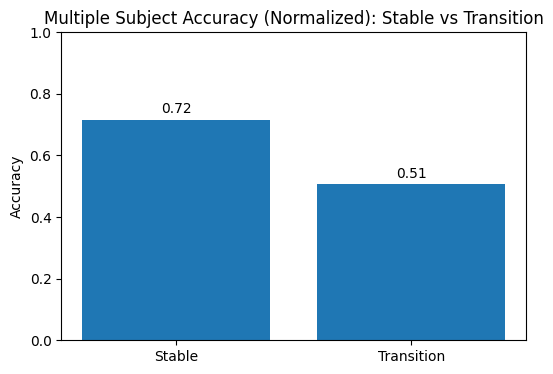

In [12]:
stable_acc = summary.loc[0, "stable_accuracy"]
transition_acc = summary.loc[0, "transition_accuracy"]

labels = ["Stable", "Transition"]
values = [stable_acc, transition_acc]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.ylim(0,1)
plt.title("Multiple Subject Accuracy (Normalized): Stable vs Transition")
plt.ylabel("Accuracy")

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

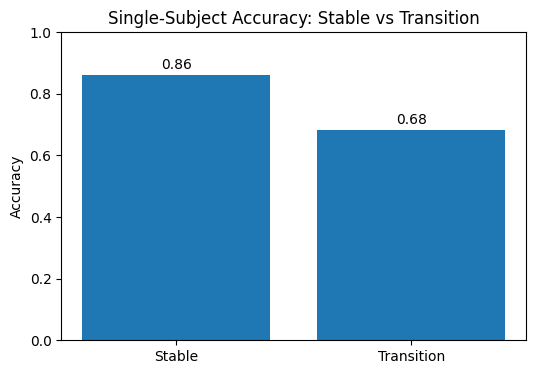

In [11]:
# replace these with your actual values from single-subject run
stable_acc = 0.8622754491017964
transition_acc = 0.6818181818181818

labels = ["Stable", "Transition"]
values = [stable_acc, transition_acc]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.ylim(0,1)
plt.title("Single-Subject Accuracy: Stable vs Transition")
plt.ylabel("Accuracy")

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

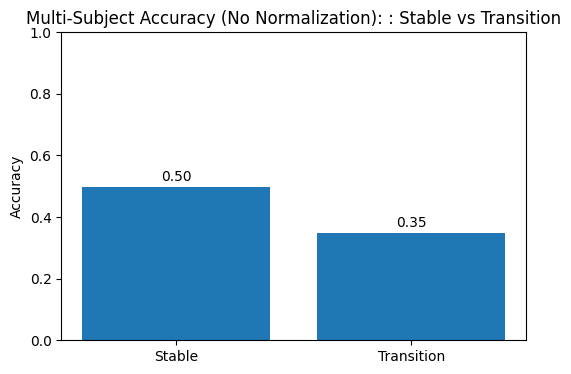

In [13]:
# replace with your actual values from the no-normalization run
stable_acc = 0.4970853206147324
transition_acc = 0.3488372093023256

labels = ["Stable", "Transition"]
values = [stable_acc, transition_acc]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.ylim(0,1)
plt.title("Multi-Subject Accuracy (No Normalization): : Stable vs Transition")
plt.ylabel("Accuracy")

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

In [5]:
from sklearn.metrics import confusion_matrix

stable_mask = test_meta["is_transition"] == False
transition_mask = test_meta["is_transition"] == True

y_true_stable = test_meta.loc[stable_mask, "y_true"]
y_pred_stable = test_meta.loc[stable_mask, "y_pred"]

y_true_trans = test_meta.loc[transition_mask, "y_true"]
y_pred_trans = test_meta.loc[transition_mask, "y_pred"]

cm_stable = confusion_matrix(y_true_stable, y_pred_stable, labels=[0,1,2,3,4])
cm_trans = confusion_matrix(y_true_trans, y_pred_trans, labels=[0,1,2,3,4])

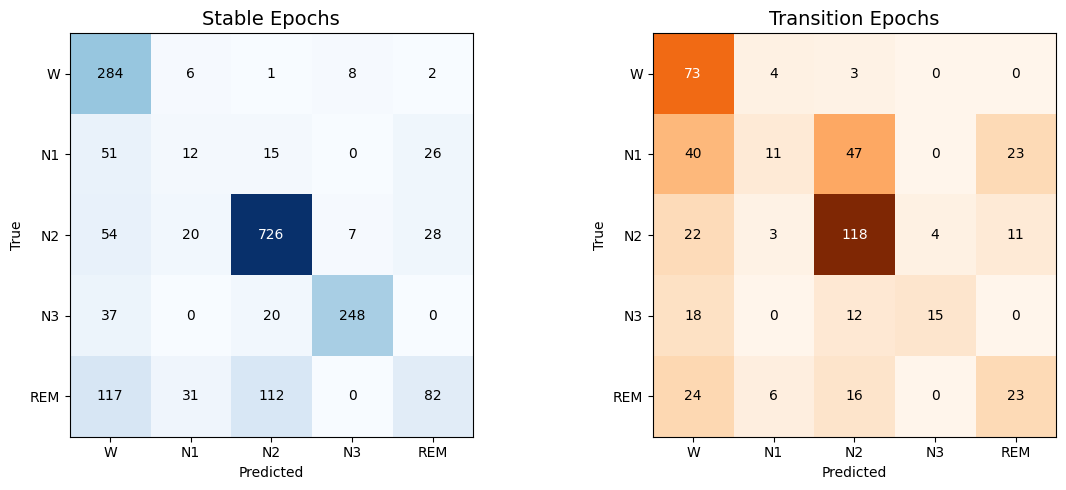

In [8]:
import matplotlib.pyplot as plt

stage_labels = ["W", "N1", "N2", "N3", "REM"]

fig, axs = plt.subplots(1, 2, figsize=(12,5))

# --- Stable ---
im0 = axs[0].imshow(cm_stable, cmap="Blues", vmin=0)
axs[0].set_title("Stable Epochs", fontsize=14)
axs[0].set_xticks(range(5))
axs[0].set_yticks(range(5))
axs[0].set_xticklabels(stage_labels)
axs[0].set_yticklabels(stage_labels)
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("True")

# add numbers with dynamic color
for i in range(cm_stable.shape[0]):
    for j in range(cm_stable.shape[1]):
        val = cm_stable[i, j]
        color = "white" if val > cm_stable.max() * 0.5 else "black"
        axs[0].text(j, i, f"{val}", ha="center", va="center", color=color, fontsize=10)

# --- Transition ---
im1 = axs[1].imshow(cm_trans, cmap="Oranges", vmin=0)
axs[1].set_title("Transition Epochs", fontsize=14)
axs[1].set_xticks(range(5))
axs[1].set_yticks(range(5))
axs[1].set_xticklabels(stage_labels)
axs[1].set_yticklabels(stage_labels)
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("True")

# add numbers with dynamic color
for i in range(cm_trans.shape[0]):
    for j in range(cm_trans.shape[1]):
        val = cm_trans[i, j]
        color = "white" if val > cm_trans.max() * 0.5 else "black"
        axs[1].text(j, i, f"{val}", ha="center", va="center", color=color, fontsize=10)

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd

def per_stage_accuracy(df, mask):
    results = {}
    for stage in [0,1,2,3,4]:
        sub = df[mask & (df["y_true"] == stage)]
        if len(sub) == 0:
            continue
        acc = (sub["y_true"] == sub["y_pred"]).mean()
        results[stage] = acc
    return results

stable_stage_acc = per_stage_accuracy(test_meta, stable_mask)
transition_stage_acc = per_stage_accuracy(test_meta, transition_mask)

stage_names = {0:"W", 1:"N1", 2:"N2", 3:"N3", 4:"REM"}

print("Stable per-stage accuracy:")
for k,v in stable_stage_acc.items():
    print(stage_names[k], ":", round(v,3))

print("\nTransition per-stage accuracy:")
for k,v in transition_stage_acc.items():
    print(stage_names[k], ":", round(v,3))

Stable per-stage accuracy:
W : 0.944
N1 : 0.115
N2 : 0.869
N3 : 0.813
REM : 0.24

Transition per-stage accuracy:
W : 0.912
N1 : 0.091
N2 : 0.747
N3 : 0.333
REM : 0.333


In [10]:
comparison = pd.DataFrame([
    {
        "Setting": "Single Subject",
        "Normalization": "N/A",
        "Stable Accuracy": 0.862,
        "Transition Accuracy": 0.682
    },
    {
        "Setting": "Multi Subject",
        "Normalization": "No",
        "Stable Accuracy": 0.497,
        "Transition Accuracy": 0.349
    },
    {
        "Setting": "Multi Subject",
        "Normalization": "Yes",
        "Stable Accuracy": 0.716,
        "Transition Accuracy": 0.507
    }
])

comparison["Gap"] = comparison["Stable Accuracy"] - comparison["Transition Accuracy"]

comparison

,Setting,Normalization,Stable Accuracy,Transition Accuracy,Gap
0,Single Subject,N/A,0.862,0.682,0.180
1,Multi Subject,No,0.497,0.349,0.148
2,Multi Subject,Yes,0.716,0.507,0.209


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

stage_names = {0:"W", 1:"N1", 2:"N2", 3:"N3", 4:"REM"}

def per_stage_accuracy(df, mask):
    results = []
    for stage in [0,1,2,3,4]:
        sub = df[mask & (df["y_true"] == stage)]
        if len(sub) == 0:
            acc = np.nan
        else:
            acc = (sub["y_true"] == sub["y_pred"]).mean()
        results.append(acc)
    return results

stable_accs = per_stage_accuracy(test_meta, stable_mask)
transition_accs = per_stage_accuracy(test_meta, transition_mask)

# create dataframe (useful for printing / saving)
df_stage = pd.DataFrame({
    "Stage": ["W","N1","N2","N3","REM"],
    "Stable": stable_accs,
    "Transition": transition_accs
})

print(df_stage)

  Stage    Stable  Transition
0     W  0.943522    0.912500
1    N1  0.115385    0.090909
2    N2  0.869461    0.746835
3    N3  0.813115    0.333333
4   REM  0.239766    0.333333


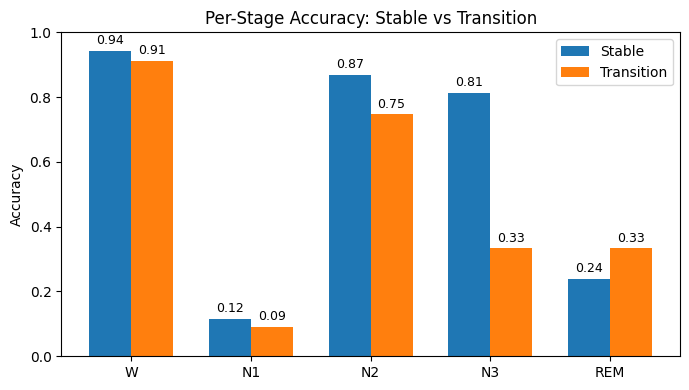

In [15]:
labels = df_stage["Stage"]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7,4))

plt.bar(x - width/2, df_stage["Stable"], width, label="Stable")
plt.bar(x + width/2, df_stage["Transition"], width, label="Transition")

plt.xticks(x, labels)
plt.ylim(0,1)
plt.title("Per-Stage Accuracy: Stable vs Transition")
plt.ylabel("Accuracy")
plt.legend()

# add values
for i in range(len(labels)):
    plt.text(i - width/2, df_stage["Stable"][i] + 0.02,
             f"{df_stage['Stable'][i]:.2f}", ha='center', fontsize=9)
    plt.text(i + width/2, df_stage["Transition"][i] + 0.02,
             f"{df_stage['Transition'][i]:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()